## **RFM 분석을 활용한 고객 세분화(Customer Segmentation)**
___
<br>

### **- 프로젝트 개요**

본 프로젝트는 대형마트 고객 데이터를 활용하여 **RFM(Recency, Frequency, Monetary) 분석**을 수행하고, 고객을 구매 특성에 따라 세분화하고자 한다.

고객별 마지막 구매일, 구매 빈도, 구매 금액을 기반으로 RFM 지표를 산출하고 점수를 부여하여, **매출에 크게 기여하는 핵심 고객군을 식별**하고, 해당 고객들의 **인구통계학적 특성 및 소비 성향을 분석**하여 고객 관리(CRM) 및 마케팅 전략 수립에 활용할 수 있는 인사이트를 도출하는 것을 목표로 한다.

### **- 프로젝트 구성**

- 데이터 전처리 및 결측치 처리
- 탐색적 데이터 분석(EDA)
- 고객별 RFM 지표(Recency, Frequency, Monetary) 계산
- RFM 점수 산출
- 고객 세분화(Segmentation)
- 고객 특성 분석 및 비즈니스 인사이트 도출

### **- 데이터셋**

- 데이터명 : Retail Customer Dataset
- 데이터 출처 : 가상의 대형 마트 고객 구매 행동을 바탕으로 제작된 실습용 모의 데이터
- 데이터셋은 고객의 기본 정보, 구매 이력, 구매 채널, 프로모션 참여 여부 및 매출 정보로 구성되어 있으며,
RFM 분석을 수행하기 위한 고객 데이터로 구성되어 있다. <br>

#### **- 데이터 설명**

| 구분 | 컬럼 | 설명 |
|------|------|------|
| 고객 정보 | ID | 고객 식별자 |
|  | signup_ym | 가입 연월 |
|  | birth_year | 출생 연도 |
|  | annual_income | 연 소득 |
|  | marital_status | 혼인 상태 |
|  | children | 부양 자녀 수 |
| 구매 정보 | recency | 마지막 구매 후 경과 일수 |
|  | amount_alcohol | 주류 구매 금액 |
|  | amount_fruit | 과일 구매 금액 |
|  | amount_meat | 육류 구매 금액 |
|  | amount_fish | 수산물 구매 금액 |
|  | amount_snack | 과자 구매 금액 |
|  | amount_general | 잡화 구매 금액 |
| 구매 채널 | num_purchase_web | 웹 구매 횟수 |
|  | num_purchase_store | 매장 구매 횟수 |
|  | num_purchase_discount | 할인 구매 횟수 |
| 프로모션 | promotion_1 ~ promotion_6 | 각 프로모션 참여 여부 (1: 참여, 0: 미참여) |
| 성과 | revenue | 총 구매 금액(매출) |

### **1. Import ibraries**

In [352]:
# =====================================
# 라이브러리 불러오기
# =====================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings(action="ignore")
plt.rc("font", family="NanumGothic")

### **2. Data loading**

In [353]:
# =====================================
# 데이터 불러오기
# =====================================

customer_df = pd.read_csv("Retail Customer Dataset.csv", sep="\t")
customer_df.head()

,ID,signup_ym,birth_year,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
0,5524,2020-12,1965,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,8,4,3,0,0,0,0,0,1,11
1,2174,2022-06,1962,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,1,2,2,0,0,0,0,0,0,11
2,4141,2021-11,1973,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,8,10,1,0,0,0,0,0,0,11
3,6182,2022-05,1992,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,2,4,2,0,0,0,0,0,0,11
4,5324,2022-04,1989,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,5,6,5,0,0,0,0,0,0,11


In [354]:
# =====================================
# 데이터 확인
# =====================================

pd.set_option("display.max_columns", None)
customer_df.head()

,ID,signup_ym,birth_year,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
0,5524,2020-12,1965,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,8,4,3,0,0,0,0,0,1,11
1,2174,2022-06,1962,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,1,2,2,0,0,0,0,0,0,11
2,4141,2021-11,1973,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,8,10,1,0,0,0,0,0,0,11
3,6182,2022-05,1992,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,2,4,2,0,0,0,0,0,0,11
4,5324,2022-04,1989,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,5,6,5,0,0,0,0,0,0,11


In [355]:
customer_df.tail()

,ID,signup_ym,birth_year,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
2235,10870,2021-09,1975,79589900.0,배우자 있음,1,46,921700,55900,236600,54600,153400,321100,9,4,2,0,0,0,0,0,0,11
2236,4001,2022-09,1954,83218200.0,배우자 있음,3,56,527800,0,39000,0,0,10400,8,5,7,1,0,0,0,0,0,11
2237,7270,2022-04,1989,74075300.0,이혼,0,91,1180400,62400,282100,41600,15600,31200,2,13,1,0,0,0,1,0,0,11
2238,8235,2022-04,1964,90018500.0,배우자 있음,1,8,556400,39000,278200,104000,39000,79300,6,10,2,0,0,0,0,0,0,11
2239,9405,2021-01,1962,68729700.0,배우자 있음,2,40,109200,3900,79300,2600,1300,27300,3,4,3,0,0,0,0,0,1,11


### **3. Preprocessing**

#### **3-1. missing values**

In [356]:
# 데이터 정보 확인
print(customer_df.shape)
customer_df.info()

(2240, 23)
<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID                     2240 non-null   int64  
 1   signup_ym              2240 non-null   str    
 2   birth_year             2240 non-null   int64  
 3   annual_income          2216 non-null   float64
 4   marital_status         2240 non-null   str    
 5   children               2240 non-null   int64  
 6   recency                2240 non-null   int64  
 7   amount_alcohol         2240 non-null   int64  
 8   amount_fruit           2240 non-null   int64  
 9   amount_meat            2240 non-null   int64  
 10  amount_fish            2240 non-null   int64  
 11  amount_snack           2240 non-null   int64  
 12  amount_general         2240 non-null   int64  
 13  num_purchase_web       2240 non-null   int64  
 14  num_purchase_store     2240 non-null   int64  
 15  num_

In [357]:
# 결측값 확인
print(customer_df.isna().sum())

ID                        0
signup_ym                 0
birth_year                0
annual_income            24
marital_status            0
children                  0
recency                   0
amount_alcohol            0
amount_fruit              0
amount_meat               0
amount_fish               0
amount_snack              0
amount_general            0
num_purchase_web          0
num_purchase_store        0
num_purchase_discount     0
promotion_1               0
promotion_2               0
promotion_3               0
promotion_4               0
promotion_5               0
promotion_6               0
revenue                   0
dtype: int64


    → 2240x23 데이터이며, annual_income(연소득) 컬럼에 24개 결측값 존재 

In [358]:
# annual_income 컬럼에 결측값이 있는 데이터 확인
customer_df[customer_df.isna().any(axis=1)] 

,ID,signup_ym,birth_year,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
10,1994,2022-02,1991,NaN,배우자 있음,1,11,6500,6500,7800,0,2600,1300,1,2,1,0,0,0,0,0,0,11
27,5255,2021-05,1994,NaN,미혼,1,19,6500,1300,3900,3900,341900,470600,27,0,0,0,0,0,0,0,0,11
43,7281,2022-02,1967,NaN,미혼,0,80,105300,14300,65000,3900,2600,50700,1,4,1,0,0,0,0,0,0,11
48,7244,2022-03,1959,NaN,미혼,3,96,62400,6500,62400,7800,13000,9100,2,4,3,0,0,0,0,0,0,11
58,8557,2021-09,1990,NaN,미혼,1,57,14300,3900,28600,2600,2600,7800,2,3,2,0,0,0,0,0,0,11
71,10629,2020-12,1981,NaN,배우자 있음,1,25,32500,3900,55900,22100,5200,22100,3,3,3,0,0,0,0,0,0,11
90,8996,2021-02,1965,NaN,배우자 있음,3,4,299000,54600,249600,63700,48100,68900,7,8,12,0,0,0,0,0,0,11
91,9235,2022-08,1965,NaN,미혼,2,45,9100,0,10400,2600,0,1300,1,2,1,0,0,0,0,0,0,11
92,5798,2022-02,1981,NaN,배우자 있음,0,87,578500,48100,466700,127400,36400,23400,2,8,1,0,0,0,0,0,0,11
128,8268,2021-10,1969,NaN,배우자 있음,1,23,457600,0,35100,13000,0,19500,6,7,3,0,0,0,0,0,0,11


    → 24개 데이터는 전체 데이터의 1% 수준이니 분석에 큰 영향을 미치지 않을 것으로 보여 결측값 전부 제거

In [359]:
# 결측값 제거
customer_df = customer_df.dropna()
customer_df.isna().sum()

ID                       0
signup_ym                0
birth_year               0
annual_income            0
marital_status           0
children                 0
recency                  0
amount_alcohol           0
amount_fruit             0
amount_meat              0
amount_fish              0
amount_snack             0
amount_general           0
num_purchase_web         0
num_purchase_store       0
num_purchase_discount    0
promotion_1              0
promotion_2              0
promotion_3              0
promotion_4              0
promotion_5              0
promotion_6              0
revenue                  0
dtype: int64

In [360]:
# 기술통계량 확인
customer_df.describe(include="all")

,ID,signup_ym,birth_year,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
count,2216.000000,2216,2216.000000,2.216000e+03,2216,2216.000000,2216.000000,2.216000e+03,2216.000000,2.216000e+03,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.0
unique,NaN,24,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,2021-12,NaN,NaN,배우자 있음,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,111,NaN,NaN,1430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5588.353339,NaN,1976.820397,6.792143e+07,NaN,0.947202,49.012635,3.966191e+05,34262.861011,2.170947e+05,48928.925993,35137.545126,57154.828520,4.085289,5.800993,2.323556,0.064079,0.013538,0.073556,0.074007,0.073105,0.150271,11.0
std,3249.376275,NaN,11.985554,3.272500e+07,NaN,0.749062,28.948352,4.385263e+05,51732.091474,2.915683e+05,71177.707139,53393.659367,67360.038687,2.740951,3.250785,1.923716,0.244950,0.115588,0.261106,0.261842,0.260367,0.357417,0.0
min,0.000000,NaN,1901.000000,2.249000e+06,NaN,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.0
25%,2814.750000,NaN,1967.000000,4.589390e+07,NaN,0.000000,24.000000,3.120000e+04,2600.000000,2.080000e+04,3900.000000,1300.000000,11700.000000,2.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.0
50%,5458.500000,NaN,1978.000000,6.679595e+07,NaN,1.000000,49.000000,2.268500e+05,10400.000000,8.840000e+04,15600.000000,10400.000000,31850.000000,4.000000,5.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.0
75%,8421.750000,NaN,1985.000000,8.907860e+07,NaN,1.000000,74.000000,6.565000e+05,42900.000000,3.019250e+05,65000.000000,42900.000000,72800.000000,6.000000,8.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.0


In [361]:
customer_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,2216.0,NaN,NaN,NaN,5588.353339,3249.376275,0.0,2814.75,5458.5,8421.75,11191.0
signup_ym,2216,24,2021-12,111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
birth_year,2216.0,NaN,NaN,NaN,1976.820397,11.985554,1901.0,1967.0,1978.0,1985.0,2004.0
annual_income,2216.0,NaN,NaN,NaN,67921426.759928,32724999.659172,2249000.0,45893900.0,66795950.0,89078600.0,866665800.0
marital_status,2216,4,배우자 있음,1430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
children,2216.0,NaN,NaN,NaN,0.947202,0.749062,0.0,0.0,1.0,1.0,3.0
recency,2216.0,NaN,NaN,NaN,49.012635,28.948352,0.0,24.0,49.0,74.0,99.0
amount_alcohol,2216.0,NaN,NaN,NaN,396619.088448,438526.296152,0.0,31200.0,226850.0,656500.0,1940900.0
amount_fruit,2216.0,NaN,NaN,NaN,34262.861011,51732.091474,0.0,2600.0,10400.0,42900.0,258700.0
amount_meat,2216.0,NaN,NaN,NaN,217094.720217,291568.254587,0.0,20800.0,88400.0,301925.0,2242500.0


In [362]:
customer_df["ID"].nunique() # ID는 전부 고유의 값으로 존재함

2216

In [363]:
# 데이터 타입 확인
customer_df.dtypes

ID                         int64
signup_ym                    str
birth_year                 int64
annual_income            float64
marital_status               str
children                   int64
recency                    int64
amount_alcohol             int64
amount_fruit               int64
amount_meat                int64
amount_fish                int64
amount_snack               int64
amount_general             int64
num_purchase_web           int64
num_purchase_store         int64
num_purchase_discount      int64
promotion_1                int64
promotion_2                int64
promotion_3                int64
promotion_4                int64
promotion_5                int64
promotion_6                int64
revenue                    int64
dtype: object

 * 데이터 타입이 str인 경우

In [364]:
columns_str_dtype = customer_df.columns[customer_df.dtypes == "str"]
columns_str_dtype

Index(['signup_ym', 'marital_status'], dtype='str')

In [365]:
# str 타입의 데이터 값 확인
for col in columns_str_dtype:
    unique_values = sorted(customer_df[col].unique())
    print(f'{col}: {len(unique_values)}개')
    print(unique_values, "\n")

signup_ym: 24개
['2020-10', '2020-11', '2020-12', '2021-01', '2021-02', '2021-03', '2021-04', '2021-05', '2021-06', '2021-07', '2021-08', '2021-09', '2021-10', '2021-11', '2021-12', '2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07', '2022-08', '2022-09'] 

marital_status: 4개
['미혼', '배우자 있음', '사별', '이혼'] 



    → signup_ym에는 2020년 10월부터 2022년 9월까지의 연월 값이 담겨 있고, marital_status에는 혼인 상태와 관련된 4가지 항목 존재

#### **3-2. feature engineering**
 - 출생 연도를 나이로 바꾸기 (기준 시점: 2023년 1월)
 - 구매 금액 합계 및 구매 횟수 합계 계산
 - 불필요한 컬럼 정리

In [366]:
# 데이터 전처리
customer_df["birth_year"]  = 2023 - customer_df["birth_year"] 
customer_df = customer_df.rename(columns={"birth_year": "age"})
customer_df.head()

,ID,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
0,5524,2020-12,58,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,8,4,3,0,0,0,0,0,1,11
1,2174,2022-06,61,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,1,2,2,0,0,0,0,0,0,11
2,4141,2021-11,50,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,8,10,1,0,0,0,0,0,0,11
3,6182,2022-05,31,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,2,4,2,0,0,0,0,0,0,11
4,5324,2022-04,34,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,5,6,5,0,0,0,0,0,0,11


In [367]:
# 주류, 과일, 육류, 수산물, 과자, 잡화 구매금액
customer_df[["amount_alcohol", "amount_fruit", "amount_meat", "amount_fish", "amount_snack", "amount_general"]]

,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general
0,825500,114400,709800,223600,114400,114400
1,14300,1300,7800,2600,1300,7800
2,553800,63700,165100,144300,27300,54600
3,14300,5200,26000,13000,3900,6500
4,224900,55900,153400,59800,35100,19500
...,...,...,...,...,...,...
2235,921700,55900,236600,54600,153400,321100
2236,527800,0,39000,0,0,10400
2237,1180400,62400,282100,41600,15600,31200
2238,556400,39000,278200,104000,39000,79300


In [368]:
# 웹 페이지를 통한 구매 횟수, 매장 방문을 통한 구매 횟수, 할인을 통한 구매 횟수
customer_df[["num_purchase_web", "num_purchase_store", 'num_purchase_discount"]]

,num_purchase_web,num_purchase_store,num_purchase_discount
0,8,4,3
1,1,2,2
2,8,10,1
3,2,4,2
4,5,6,5
...,...,...,...
2235,9,4,2
2236,8,5,7
2237,2,13,1
2238,6,10,2


 - 품목별 구매 금액의 합계인 amount_total 컬럼을 amount_general 컬럼 뒤에 추가

In [369]:
# 품목별 구매 금액의 합계
data_amount_total = (
    customer_df["amount_alcohol"]
    + customer_df["amount_fruit"]
    + customer_df["amount_meat"]
    + customer_df["amount_fish"]
    + customer_df["amount_snack"]
    + customer_df["amount_general"]
)

In [370]:
idx_amount_general = customer_df.columns.get_loc("amount_general")
customer_df.insert( # 컬럼 추가
        loc=idx_amount_general+1, # 인덱스+1 위치에 추가
        column="amount_total", # 추가할 컬럼명
        value=data_amount_total
)
customer_df.head()

,ID,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
0,5524,2020-12,58,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,0,0,0,0,0,1,11
1,2174,2022-06,61,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,0,0,0,0,0,0,11
2,4141,2021-11,50,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,0,0,0,0,0,0,11
3,6182,2022-05,31,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,0,0,0,0,0,0,11
4,5324,2022-04,34,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,0,0,0,0,0,0,11


 * 경로별 구매 횟수의 합계인 num_purchase_total 컬럼을 num_purchase_discount 컬럼 뒤에 추가

In [371]:
# 경로별 구매 횟수의 합계
num_purchase_total = (
    customer_df["num_purchase_web"]
    + customer_df["num_purchase_store"]
    + customer_df["num_purchase_discount"]
)

In [372]:
idx_num_purchase_discount = customer_df.columns.get_loc("num_purchase_discount")
customer_df.insert(  # 컬럼 추가
    loc=idx_num_purchase_discount+1, # 인덱스+1 위치에 추가
    column="num_purchase_total", # 추가할 컬럼명
    value=num_purchase_total,
)
customer_df.head()

,ID,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,revenue
0,5524,2020-12,58,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,11
1,2174,2022-06,61,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,11
2,4141,2021-11,50,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,11
3,6182,2022-05,31,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,11
4,5324,2022-04,34,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,11


- 불필요한 컬럼 정리하기

In [373]:
# 고유값인 ID를 key로 인덱스 설정
customer_df = customer_df.set_index("ID") 

In [374]:
customer_df["revenue"].describe() # 평균이 11이고 표준편차가 0 → revenue 컬럼은 전부 11이라는 값만 존재

count    2216.0
mean       11.0
std         0.0
min        11.0
25%        11.0
50%        11.0
75%        11.0
max        11.0
Name: revenue, dtype: float64

In [375]:
# 데이터 삭제 
customer_df = customer_df.drop(columns="revenue")
customer_df.head()

,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
ID,,,,,,,,,,,,,,,,,,,,,,,
5524,2020-12,58,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1
2174,2022-06,61,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0
4141,2021-11,50,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0
6182,2022-05,31,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0
5324,2022-04,34,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0


In [376]:
customer_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
signup_ym,2216,24,2021-12,111,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2216.0,NaN,NaN,NaN,46.179603,11.985554,19.0,38.0,45.0,56.0,122.0
annual_income,2216.0,NaN,NaN,NaN,67921426.759928,32724999.659172,2249000.0,45893900.0,66795950.0,89078600.0,866665800.0
marital_status,2216,4,배우자 있음,1430,NaN,NaN,NaN,NaN,NaN,NaN,NaN
children,2216.0,NaN,NaN,NaN,0.947202,0.749062,0.0,0.0,1.0,1.0,3.0
recency,2216.0,NaN,NaN,NaN,49.012635,28.948352,0.0,24.0,49.0,74.0,99.0
amount_alcohol,2216.0,NaN,NaN,NaN,396619.088448,438526.296152,0.0,31200.0,226850.0,656500.0,1940900.0
amount_fruit,2216.0,NaN,NaN,NaN,34262.861011,51732.091474,0.0,2600.0,10400.0,42900.0,258700.0
amount_meat,2216.0,NaN,NaN,NaN,217094.720217,291568.254587,0.0,20800.0,88400.0,301925.0,2242500.0
amount_fish,2216.0,NaN,NaN,NaN,48928.925993,71177.707139,0.0,3900.0,15600.0,65000.0,336700.0


### **4. Analysis - EDA**
 - 인구통계학적 고객 정보에 대한 탐색적 데이터 분석
 - **가설**: <u>나이, 연 소득, 혼인 상태, 부양 자녀 수</u>가 고객 소비성향에 영향을 미칠 것이다.
    - 나이: 구매력이 낮은 20대 이하 및 70대 이상 구간은 그 외에 비해 구매 금액 및 횟수가 낮을 것이다.
    - 연 소득: 연소득이 높을수록 구매 금액 및 횟수가 높을 것이다.
    - 혼인 상태: 기혼 상태일 경우 그 외에 비해 구매 금액 및 횟수가 높을 것이다.
    - 부양 자녀 수: 부양 자녀 수가 많을수록 구매 금액 및 횟수가 높을 것이다.


#### **4-1. 나이, 연 소득 분포**

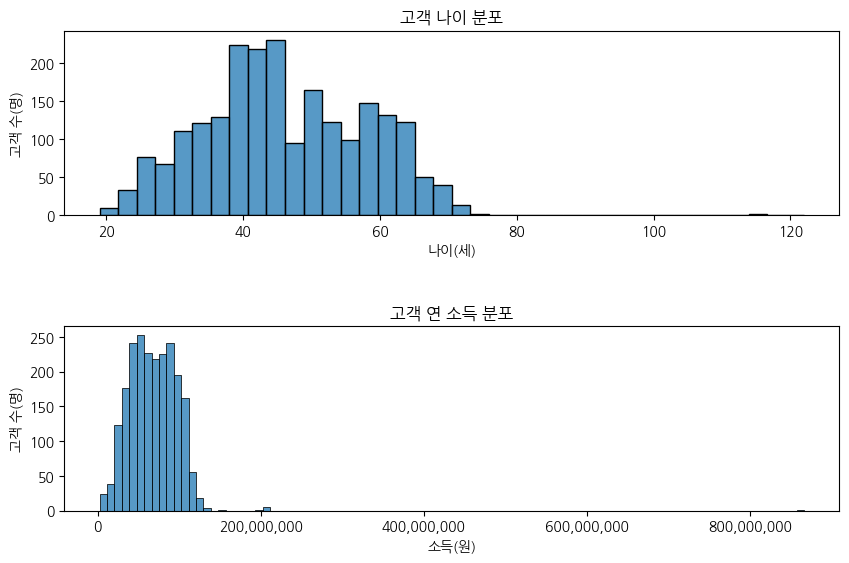

In [377]:
# 고객 나이, 연 소득 분포 데이터 시각화
# 그래프 크기 및 간격 조정
plt.rcParams["figure.figsize"] = (10, 6)
plt.subplots_adjust(left=0.125, bottom=0.1,  right=0.9, top=0.9, wspace=0.2, hspace=0.6)

# 1. 나이
plt.subplot(2,1,1)
sns.histplot(data=customer_df["age"])
plt.title("고객 나이 분포")
plt.xlabel("나이(세)")
plt.ylabel("고객 수(명)")

# 2. 연 소득 
plt.subplot(2,1,2)
sns.histplot(data=customer_df["annual_income"])
plt.title("고객 연 소득 분포")
plt.xlabel("소득(원)")
plt.ylabel("고객 수(명)")
current_values = plt.gca().get_xticks() # 눈금 설정
plt.gca().set_xticklabels([f"{x:,.0f}".format(x) for x in current_values]) 
plt.show()

    → 나이: 30대 후반~40대 초반 고객 수가 많으며, 120세에 가까운 고객이 존재함
    → 연 소득: 대부분이 2억원 이하의 소득구간에 분포하고 있으며, 8억 이상 고소득 고객이 존재함

* 나이: 100세 이상은 현실세계에서 이상치에 가까움

In [378]:
customer_df.sort_values(by="age", ascending=False)

,signup_ym,age,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
ID,,,,,,,,,,,,,,,,,,,,,,,
11004,2022-08,122,78236600.0,미혼,1,23,10400,0,6500,9100,0,2600,28600,1,2,1,4,0,0,0,0,0,0
1150,2021-12,116,108591600.0,배우자 있음,0,36,981500,187200,730600,135200,83200,291200,2408900,4,4,1,9,0,0,0,0,1,0
7829,2021-12,115,47632000.0,이혼,1,99,19500,7800,10400,9100,5200,32500,84500,2,2,1,5,0,0,0,0,0,0
6663,2021-10,75,66483300.0,미혼,0,96,187200,0,9100,0,0,7800,204100,3,4,1,8,0,0,0,0,0,0
6932,2021-07,74,120935100.0,배우자 있음,0,77,1670500,54600,930800,71500,0,27300,2754700,7,5,0,12,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4427,2020-12,20,108234100.0,미혼,0,56,696800,35100,767000,49400,139100,87100,1774500,5,12,1,18,0,0,1,0,1,1
5184,2022-06,20,45271200.0,미혼,0,65,5200,2600,14300,2600,0,5200,29900,1,2,1,4,0,0,0,0,0,0
10548,2022-06,20,92511900.0,미혼,0,30,367900,22100,483600,179400,137800,57200,1248000,3,12,1,16,0,0,0,0,0,0


In [379]:
# 이상값이 포함된 고객이 3명뿐이므로 전체 데이터에서 제거
customer_df = customer_df[customer_df["age"] < 100]

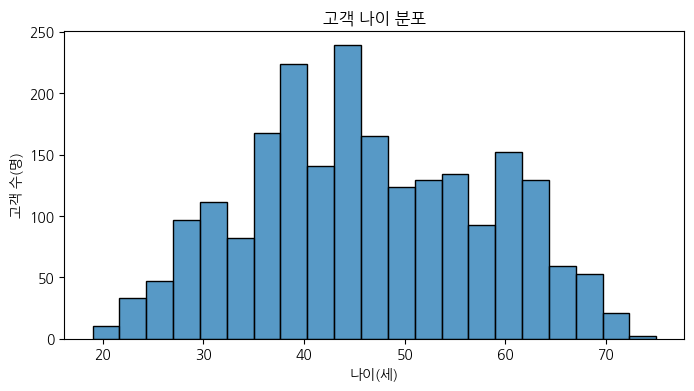

In [380]:
# 고객 나이 분포 데이터 시각화
plt.rcParams["figure.figsize"] = (8, 4)
sns.histplot(data=customer_df["age"])
plt.title("고객 나이 분포")
plt.xlabel("나이(세)")
plt.ylabel("고객 수(명)")
plt.show()

* 데이터 구간화(Binning): 연령대별 경향 및 특성 파악을 위해 나이를 10년 단위로 구간화

In [381]:
# 나이 최소, 최대값 확인
print(customer_df["age"].min(), ",", customer_df["age"].max())

19 , 75


In [382]:
# 구간화(binning)
age_bins = list(range(10, 81, 10))
age_bins

[10, 20, 30, 40, 50, 60, 70, 80]

In [383]:
age_labels = [f"{x}대" for x in age_bins[:-1]] # 70대까지만 
age_labels

['10대', '20대', '30대', '40대', '50대', '60대', '70대']

In [384]:
age_group = pd.cut(x=customer_df["age"], bins=age_bins, labels=age_labels, right=False)
age_group

ID
5524     50대
2174     60대
4141     50대
6182     30대
5324     30대
        ... 
10870    40대
4001     60대
7270     30대
8235     50대
9405     60대
Name: age, Length: 2213, dtype: category
Categories (7, str): ['10대' < '20대' < '30대' < '40대' < '50대' < '60대' < '70대']

In [385]:
# 구간화한 연령대 age_group 컬럼을 age 뒤에 추가
customer_df.insert(
    loc=customer_df.columns.get_loc("age")+1,
    column="age_group",
    value=age_group
)
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
ID,,,,,,,,,,,,,,,,,,,,,,,,
5524,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1
2174,2022-06,61,60대,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0
4141,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0
6182,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0
5324,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0


In [386]:
# 연령대별 고객 수
customer_df["age_group"].value_counts()

age_group
40대    678
30대    502
50대    485
60대    338
20대    185
70대     23
10대      2
Name: count, dtype: int64

* 특정 연령대에서 표본의 수가 너무 적으면 해당 연령대에 대한 통계 수치의 신뢰성이 떨어지고 분석 결과 역시 왜곡돼기 쉬우므로, <br>
  10대를 20대를 20대 이하로, 70대를 60대 이상으로 편입

In [387]:
# 구간 재조정
age_group_replace_dict = {
    "10대": "20대 이하",
    "20대": "20대 이하",
    "60대": "60대 이상",
    "70대": "60대 이상"
}
customer_df["age_group"] = customer_df["age_group"].astype(str).replace(age_group_replace_dict) # category 타입을 str로 변환 후 replace
customer_df["age_group"].value_counts()

age_group
40대       678
30대       502
50대       485
60대 이상    361
20대 이하    187
Name: count, dtype: int64

* 연 소득: 8억 이상의 극단값 존재. 가능은 하나, 이상치에 해당됨

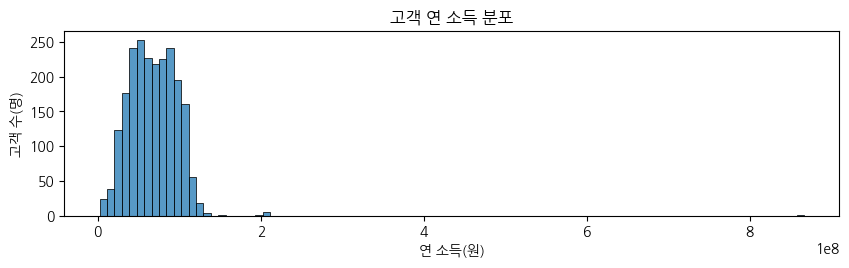

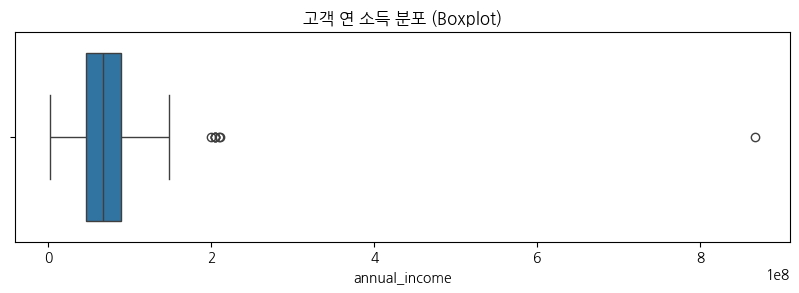

In [388]:
# 연 소득 분포 데이터 시각화
plt.rcParams["figure.figsize"] = (10, 6)
plt.subplots_adjust(left=0.125, bottom=0.1,  right=0.9, top=0.9, wspace=0.2, hspace=0.6)

# 1. 히스토그램
plt.subplot(2,1,1)
sns.histplot(data=customer_df["annual_income"])
plt.title("고객 연 소득 분포")
plt.xlabel("연 소득(원)")
plt.ylabel("고객 수(명)")
plt.show()

# 2. 박스플롯
plt.subplot(2,1,2)
sns.boxplot(data=customer_df, x="annual_income")
plt.title("고객 연 소득 분포 (Boxplot)")
plt.show()

* 소득이 예외적으로 높은 고객이 있을 시 소득과 소비 사이의 관계를 분석할 때 왜곡이 발생할 수 있고, <br>
  연 소득이 이상 범위에 있는 고객의 수가 많지 않으므로 이상치 데이터 제거


In [389]:
# IQR 방식으로 이상값 제거
income = customer_df["annual_income"]
q1 = income.quantile(0.25)
q3 = income.quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

normal_condition = (income >= lower_bound) & (income <= upper_bound)
customer_df = customer_df[normal_condition]

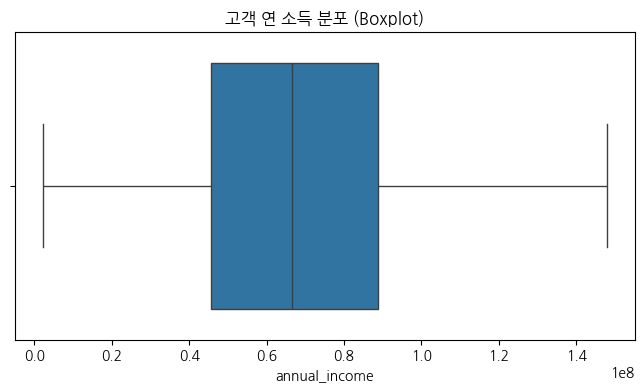

In [390]:
plt.rcParams["figure.figsize"] = (8, 4)
sns.boxplot(data=customer_df, x="annual_income")
plt.title("고객 연 소득 분포 (Boxplot)")
plt.show()

#### **4-2. 혼인 상태, 부양 자녀 수 분포**

In [391]:
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
ID,,,,,,,,,,,,,,,,,,,,,,,,
5524,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1
2174,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0
4141,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0
6182,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0
5324,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0


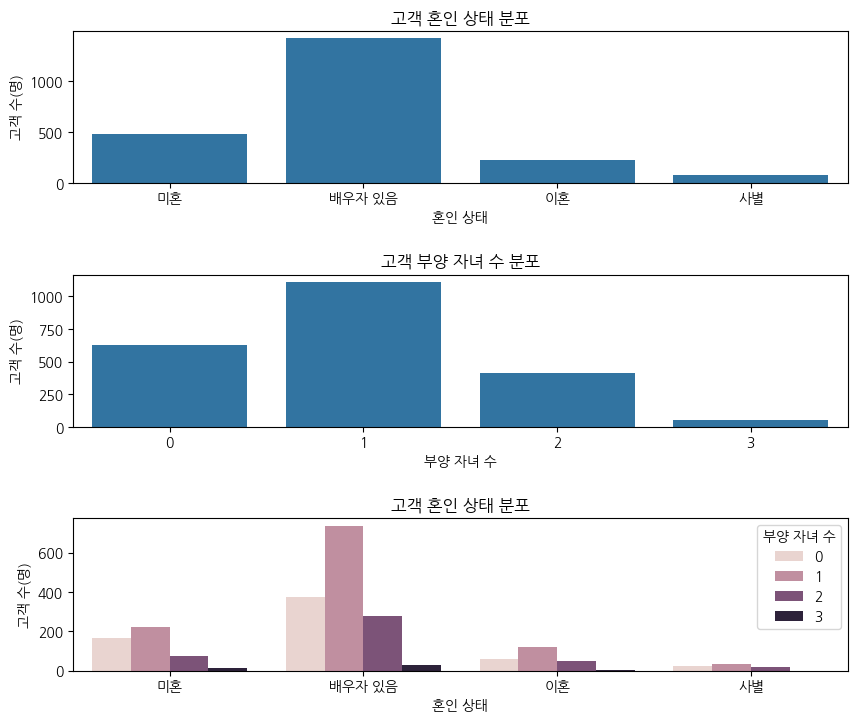

In [392]:
# 혼인 상태, 부양 자녀 수 분포 데이터 시각화
plt.rcParams["figure.figsize"] = (10, 8)
plt.subplots_adjust(left=0.125, bottom=0.1,  right=0.9, top=0.9, wspace=0.2, hspace=0.6)

# 1. 혼인 상태
plt.subplot(3,1,1)
sns.countplot(data=customer_df, x="marital_status")
plt.title("고객 혼인 상태 분포")
plt.xlabel("혼인 상태")
plt.ylabel("고객 수(명)")

# 2. 부양 자녀 수
plt.subplot(3,1,2)
sns.countplot(data=customer_df, x="children")
plt.title("고객 부양 자녀 수 분포")
plt.xlabel("부양 자녀 수")
plt.ylabel("고객 수(명)")

# 1. 혼인 상태
plt.subplot(3,1,3)
sns.countplot(data=customer_df, x="marital_status", hue="children")
plt.title("고객 혼인 상태 분포")
plt.xlabel("혼인 상태")
plt.ylabel("고객 수(명)")
plt.legend(title="부양 자녀 수") # 범례

plt.show()

In [393]:
# 데이터 비율 확인
print(round(customer_df["marital_status"].value_counts(normalize=True), 2), " \n")
print(round(customer_df["children"].value_counts(normalize=True), 2))

marital_status
배우자 있음    0.64
미혼        0.22
이혼        0.10
사별        0.03
Name: proportion, dtype: float64  

children
1    0.50
0    0.28
2    0.19
3    0.02
Name: proportion, dtype: float64


    → 배우자가 있는 고객이 과반수 이상, 부양 자녀 수가 있는 고객이 과반수 이상

#### **4-3. 가설**
- 나이, 연 소득, 혼인 상태, 부양 자녀 수가 고객 소비 성향에 영향을 미칠 것이다.

In [394]:
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
ID,,,,,,,,,,,,,,,,,,,,,,,,
5524,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1
2174,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0
4141,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0
6182,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0
5324,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0


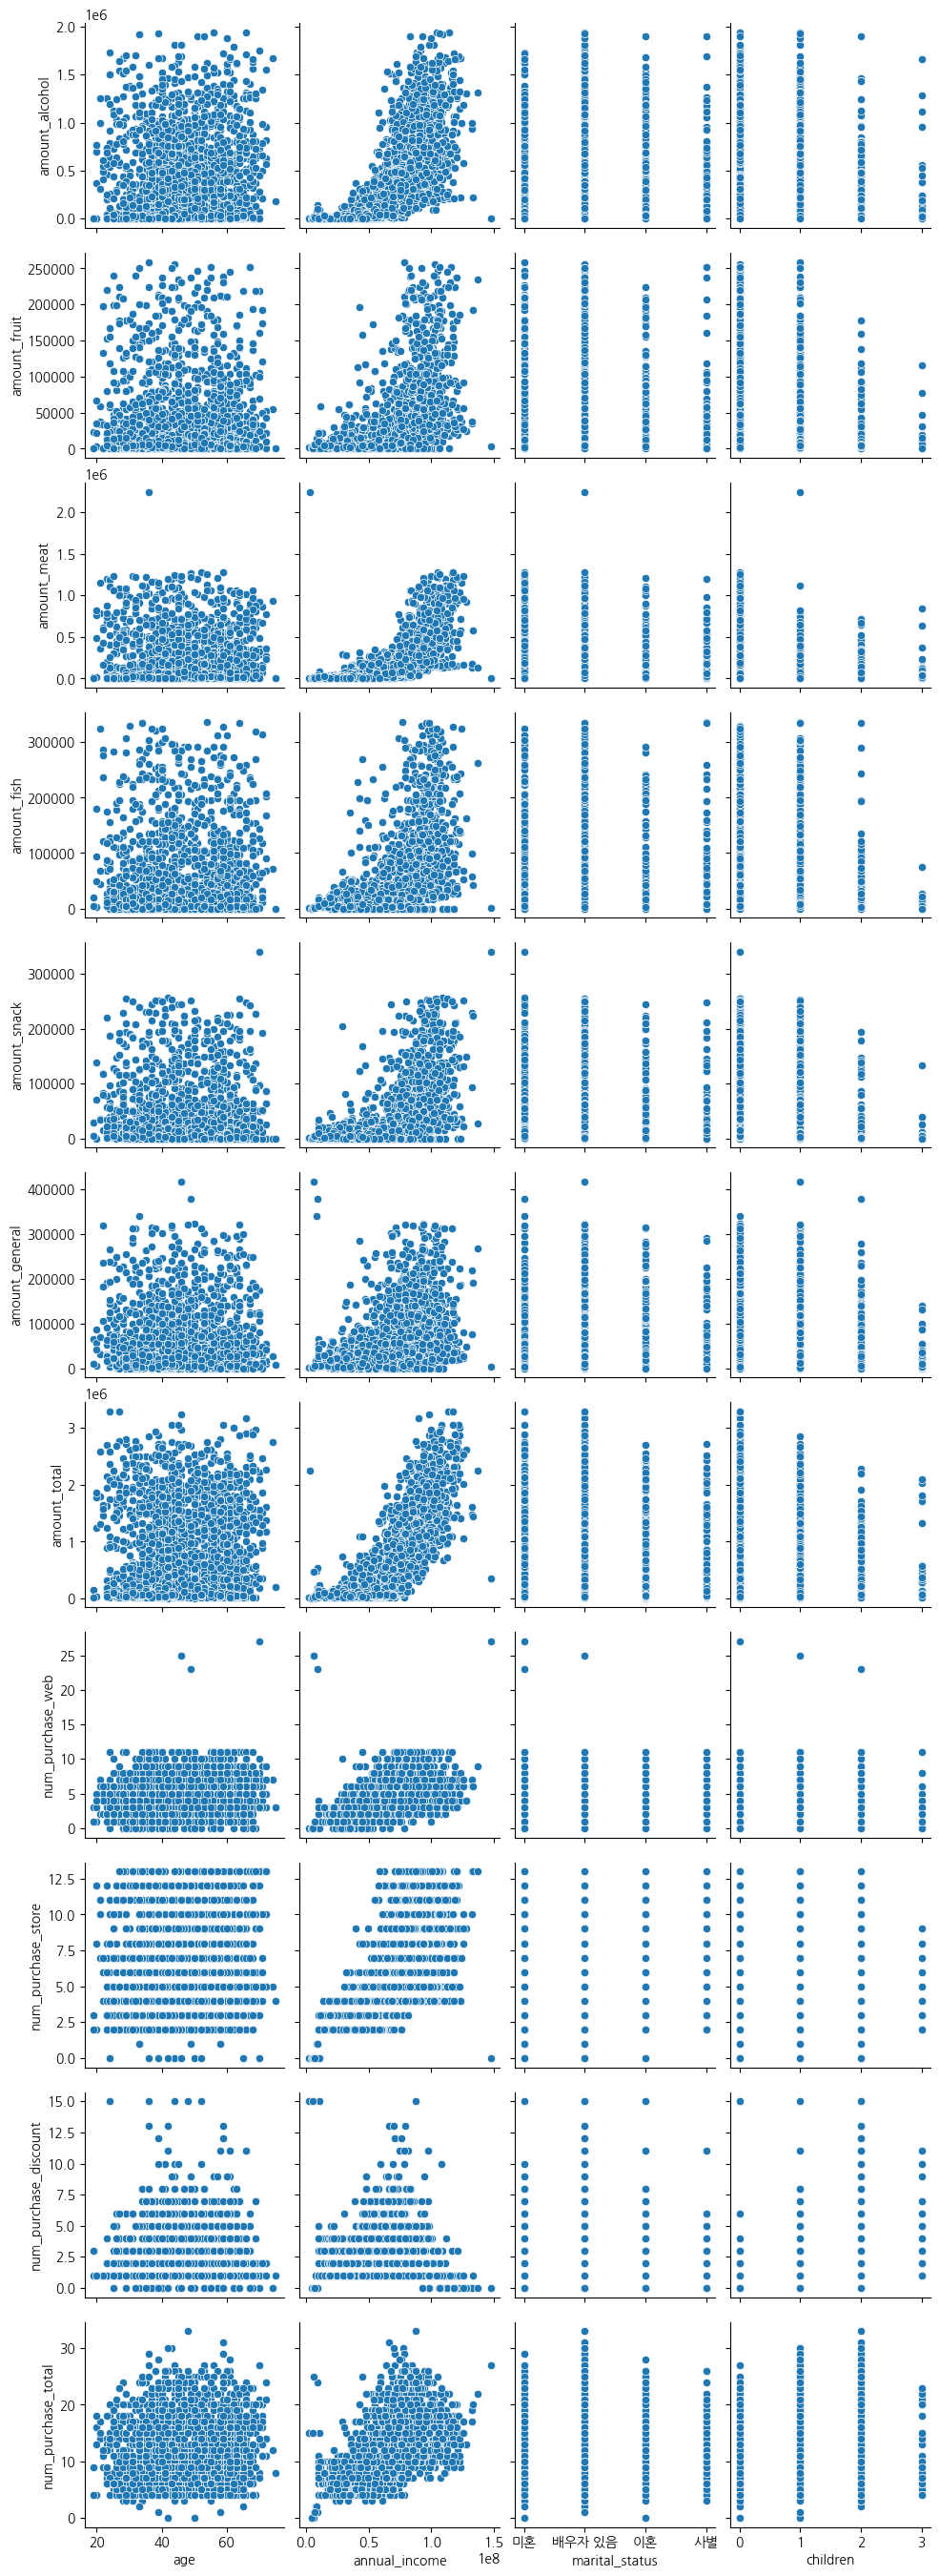

In [395]:
#고객들의 인구통계학적 특성 및 소비 성향의 연관성 확인을 위한 시각화
sns.pairplot(data=customer_df,
             x_vars=["age", "annual_income", "marital_status", "children"], 
             y_vars=["amount_alcohol", "amount_fruit", "amount_meat", "amount_fish", "amount_snack", "amount_general", "amount_total",
                     "num_purchase_web", "num_purchase_store", "num_purchase_discount", "num_purchase_total"]
)
plt.show()

    → 연 소득(annual_income)은 소비와 관련된 변수들과 어느정도 양의 선형 상관관계가 있는 것으로 보이나,
      그 외의 변수는 뚜렷한 패턴을 보이지는 않음

### **5. Analysis - RFM**
 - RFM 고객 세그먼트 분류: Recency, Frequency, Monetary 각 항목의 등급을 1, 2, 3등급으로 구분 → <u>숫자가 클수록 더 긍정적인 것으로 가정</u>

#### **5-1. Recency, Frequency, Monetary 등급 산출**

In [396]:
# 등급 개수 설정
num_grades = 3

In [397]:
#Recency, Frequency, Monetary 각 항목의 등급을 숫자로 표시하기 위한 변수
grade_labels = list(range(1, num_grades+1))
grade_labels

[1, 2, 3]

- **Recency**

In [398]:
# recency 컬럼 사용 - 마지막 구매일로부터 기준 시점까지 경과된 날
# recency 값이 작을수록 등급이 높아야 함
recency_grade = pd.qcut(x=customer_df["recency"], q=num_grades, labels=grade_labels[::-1])
recency_grade

ID
5524     2
2174     2
4141     3
6182     3
5324     1
        ..
10870    2
4001     2
7270     1
8235     3
9405     2
Name: recency, Length: 2205, dtype: category
Categories (3, int64): [3 < 2 < 1]

In [399]:
customer_df["recency_grade"] = recency_grade
recency_grade.value_counts() #비슷한 비율로 분배됨

recency
3    752
1    730
2    723
Name: count, dtype: int64

- Recency 등급에 따른 매출 기여도

In [400]:
# 1등급에서 3등급으로 갈수록 recency(마지막 구매일로부터 기준 시점까지 경과된 날) 값이 작아짐
groupby_recency_grade = customer_df.groupby("recency_grade").sum(numeric_only=True).reset_index()
groupby_recency_grade[["recency_grade", "recency"]]

,recency_grade,recency
0,3,11988
1,2,35840
2,1,60237


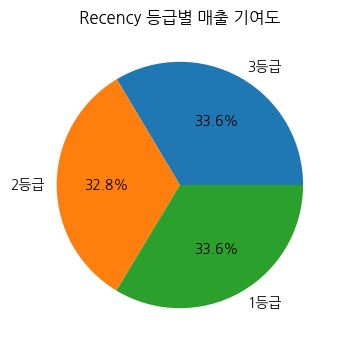

In [401]:
# Recency 등급에 따른 매출 기여도 시각화
groupby_recency_grade["amount_total"].plot(
    kind="pie",
    autopct="%.1f%%", # 각 영역의 비중 퍼센트 표시
    labels=[f"{x}등급" for x in grade_labels[::-1]],
    title="Recency 등급별 매출 기여도",
    figsize=(8, 4)
)
plt.show()

    → Recency 등급에 따른 매출 기여도의 차이가 거의 없음

- **Frequency**

In [402]:
# num_purchase_total 컬럼 사용 - 경로별 구매 횟수의 합계
# num_purchase_total 값이 클수록 등급이 높아야 함
customer_df["frequency_grade"] = pd.qcut(x=customer_df["num_purchase_total"], q=num_grades, labels=grade_labels)
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,recency_grade,frequency_grade
ID,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,2,2
2174,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,2,1
4141,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,3,3
6182,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,3,1
5324,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,1,3


In [403]:
customer_df["frequency_grade"].value_counts()

frequency_grade
1    851
2    679
3    675
Name: count, dtype: int64

- Frequency 등급에 따른 매출 기여도

In [404]:
# 1등급에서 3등급으로 갈수록 num_purchase_total(경로별 구매 횟수의 합계) 값이 커짐
groupby_frequency_grade = customer_df.groupby("frequency_grade").sum(numeric_only=True).reset_index()
groupby_frequency_grade[["frequency_grade", "num_purchase_total"]]

,frequency_grade,num_purchase_total
0,1,5402
1,2,8483
2,3,13110


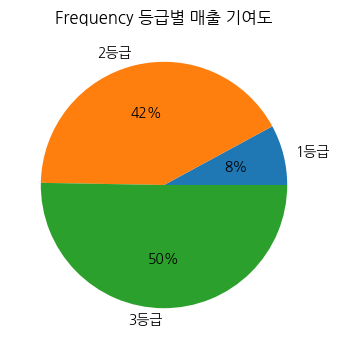

In [405]:
# Frequency 등급에 따른 매출 기여도 시각화
groupby_frequency_grade["amount_total"].plot(
    kind="pie",
    autopct="%.f%%", # 각 영역의 비중 퍼센트 표시
    labels=[f"{x}등급" for x in grade_labels],
    title="Frequency 등급별 매출 기여도",
    figsize=(8, 4)
)
plt.show()

    → Frequency 등급에 따라 매출 기여도의 차이가 존재함(3등급-2등급-1등급 순)
    → 1등급 고객의 수(851명)가 타 등급에 비해 더 많음에도, 1등급의 매출 기여도가 8%로 매우 낮음

* **Monetary**

In [406]:
# amount_total 컬럼 사용 - 품목별 구매 금액의 합계
# amount_total 값이 클수록 등급이 높아야 함
customer_df["monetary_grade"] = pd.qcut(x=customer_df["amount_total"], q=num_grades, labels=grade_labels)
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,recency_grade,frequency_grade,monetary_grade
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,2,2,3
2174,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,2,1,1
4141,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,3,3,2
6182,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,3,1,1
5324,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,1,3,2


In [407]:
customer_df["monetary_grade"].value_counts()

monetary_grade
1    735
2    735
3    735
Name: count, dtype: int64

* Monetary 등급에 따른 매출 기여도

In [408]:
# 1등급에서 3등급으로 갈수록 amount_total(품목별 구매 금액의 합계) 값이 커짐
groupby_monetary_grade = customer_df.groupby("monetary_grade").sum(numeric_only=True).reset_index()
groupby_monetary_grade[["monetary_grade", "amount_total"]]

,monetary_grade,amount_total
0,1,49251800
1,2,397077200
2,3,1293125600


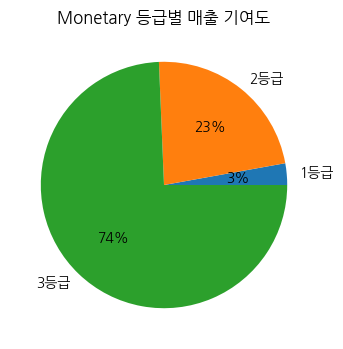

In [409]:
# Monetary 등급에 따른 매출 기여도 시각화
groupby_monetary_grade["amount_total"].plot(
    kind="pie",
    autopct="%.f%%", # 각 영역의 비중 퍼센트 표시
    labels=[f"{x}등급" for x in grade_labels],
    title="Monetary 등급별 매출 기여도",
    figsize=(8, 4)
)
plt.show()

    → Monetary 등급에 따라 매출 기여도의 차이가 명확함(3등급-2등급-1등급 순)

#### **5-2. 가중합을 이용한 RFM 고객 세그먼트 분류**
<!-- - RFM 고객 세그먼트의 등급 개수를 3개로 설정 -->

* RFM 세 항목에 동일한 가중치를 설정할 경우

In [410]:
# RFM 항목별 가중치 설정
weight = {}
weight["w_recency"] = 1/3
weight["w_frequency"] = 1/3
weight["w_monetary"] = 1/3
weight

{'w_recency': 0.3333333333333333,
 'w_frequency': 0.3333333333333333,
 'w_monetary': 0.3333333333333333}

In [411]:
customer_df.dtypes #각 항목의 등급이 숫자로 표시되어 있지만, 모두 범주형 데이터임 (1, 2, 3등급)

signup_ym                     str
age                         int64
age_group                     str
annual_income             float64
marital_status                str
children                    int64
recency                     int64
amount_alcohol              int64
amount_fruit                int64
amount_meat                 int64
amount_fish                 int64
amount_snack                int64
amount_general              int64
amount_total                int64
num_purchase_web            int64
num_purchase_store          int64
num_purchase_discount       int64
num_purchase_total          int64
promotion_1                 int64
promotion_2                 int64
promotion_3                 int64
promotion_4                 int64
promotion_5                 int64
promotion_6                 int64
recency_grade            category
frequency_grade          category
monetary_grade           category
dtype: object

In [412]:
# 가중합 계산
# 등급 값이 1, 2, 3으로 한정되어 있으므로 고객 지표의 범위는 1 이상 3 이하
customer_df["rfm_score"] = (
    weight["w_recency"] * customer_df["recency_grade"].astype("int") +
    weight["w_frequency"] * customer_df["frequency_grade"].astype("int") +
    weight["w_monetary"] * customer_df["monetary_grade"].astype("int")
)
customer_df.iloc[:, -4:]

,recency_grade,frequency_grade,monetary_grade,rfm_score
ID,,,,
5524,2,2,3,2.333333
2174,2,1,1,1.333333
4141,3,3,2,2.666667
6182,3,1,1,1.666667
5324,1,3,2,2.000000
...,...,...,...,...
10870,2,2,3,2.333333
4001,2,3,2,2.333333
7270,1,3,3,2.333333


* 고객 등급을 아래와 같이 동일한 크기의 **3개 구간으로 구간화**하여 고객 세그먼트 분류

| 고객 지표 구간 | 등급|
| -------------- | --- |
| 1 이상 5/3 미만 | 1등급 |
| 5/3 이상 7/3 이하	| 2등급 |
| 7/3 초과 3 이하 | 3등급|

In [413]:
#  rfm_score 값을 받으면 위의 기준에 따라 RFM 세그먼트를 리턴해 주는 함수 정의
def rfm_segment_bins(x):
    if x < 5/3:
        return 1
    elif x <= 7/3:
        return 2
    else:
        return 3

In [414]:
customer_df["rfm_segment"] = customer_df["rfm_score"].apply(rfm_segment_bins)
customer_df.iloc[:, -5:]

,recency_grade,frequency_grade,monetary_grade,rfm_score,rfm_segment
ID,,,,,
5524,2,2,3,2.333333,2
2174,2,1,1,1.333333,1
4141,3,3,2,2.666667,3
6182,3,1,1,1.666667,1
5324,1,3,2,2.000000,2
...,...,...,...,...,...
10870,2,2,3,2.333333,2
4001,2,3,2,2.333333,2
7270,1,3,3,2.333333,2


In [415]:
customer_df["rfm_segment"].value_counts() # 1등급에서 3등급으로 갈수록 고객 수가 적음

rfm_segment
1    926
2    811
3    468
Name: count, dtype: int64

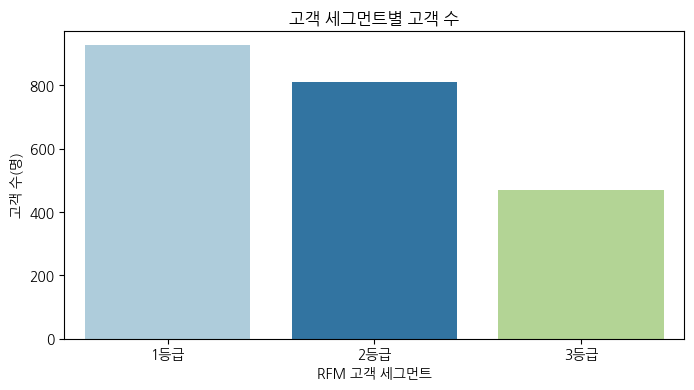

In [474]:
# RFM 고객 세그먼트별 고객 수 시각화
plt.rcParams["figure.figsize"] = (8, 4)
sns.countplot(data=customer_df, 
              x="rfm_segment",
              order=grade_labels,
              palette="Paired"
             )
plt.title("RFM 고객 세그먼트별 고객 수")
plt.xlabel("고객 세그먼트")
plt.ylabel("고객 수(명)")
plt.xticks(ticks=range(0, num_grades), # num_grades=3
           labels=[f"{x}등급" for x in grade_labels]) 
plt.show()

* 고객 세그먼트별 매출 기여도

In [418]:
groupby_rfm_segment = customer_df.groupby("rfm_segment").sum(numeric_only=True).reset_index()
groupby_rfm_segment[["rfm_segment", "amount_total"]]

,rfm_segment,amount_total
0,1,143427700
1,2,880252100
2,3,715774800


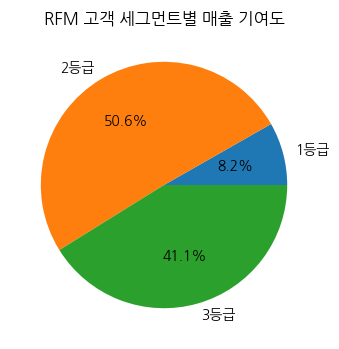

In [419]:
# RFM 고객 세그먼트별 매출 기여도 시각화
groupby_rfm_segment["amount_total"].plot(
    kind="pie",
    autopct="%.1f%%",
    labels=[f"{x}등급" for x in grade_labels],
    title="RFM 고객 세그먼트별 매출 기여도",
    figsize=(8, 4)
)
plt.show()

    → 1등급은 매출 기여도가 작으나, 2, 3등급의 기여도는 차이가 크지 않음. 매출 기여도가 크게 구분되는 세그먼트가 필요함

* 앞선 분석에서 Recency 등급은 등급별 매출 기여도 차이가 거의 없었으므로, <br>
  Recency의 가중치를 줄이면 고객 세그먼트별 매출 기여도의 차이가 더 뚜렷해질 것으로 추측

In [420]:
# 가중치 조정
weight2 = {}
weight2["w_recency"] = 0.2
weight2["w_frequency"] = 0.4
weight2["w_monetary"] = 0.4
weight2

{'w_recency': 0.2, 'w_frequency': 0.4, 'w_monetary': 0.4}

In [421]:
# 가중합 계산
# 등급 값이 1, 2, 3으로 한정되어 있으므로 고객 지표의 범위는 1 이상 3 이하
customer_df["rfm_score2"] = (
    weight2["w_recency"] * customer_df["recency_grade"].astype("int") +
    weight2["w_frequency"] * customer_df["frequency_grade"].astype("int") +
    weight2["w_monetary"] * customer_df["monetary_grade"].astype("int")
)

In [422]:
# RFM 고객 지표 구간화
customer_df["rfm_segment2"] = customer_df["rfm_score2"].apply(rfm_segment_bins)
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,recency_grade,frequency_grade,monetary_grade,rfm_score,rfm_segment,rfm_score2,rfm_segment2
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,2,2,3,2.333333,2,2.4,3
2174,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,2,1,1,1.333333,1,1.2,1
4141,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,3,3,2,2.666667,3,2.6,3
6182,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,3,1,1,1.666667,1,1.4,1
5324,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,1,3,2,2.000000,2,2.2,2


In [423]:
customer_df["rfm_segment"].value_counts()

rfm_segment
1    926
2    811
3    468
Name: count, dtype: int64

In [424]:
# 조정된 가중치가 적용된 고객 세그먼트
customer_df["rfm_segment2"].value_counts()  # 3등급 세그먼트 고객의 수 증가

rfm_segment2
1    802
3    792
2    611
Name: count, dtype: int64

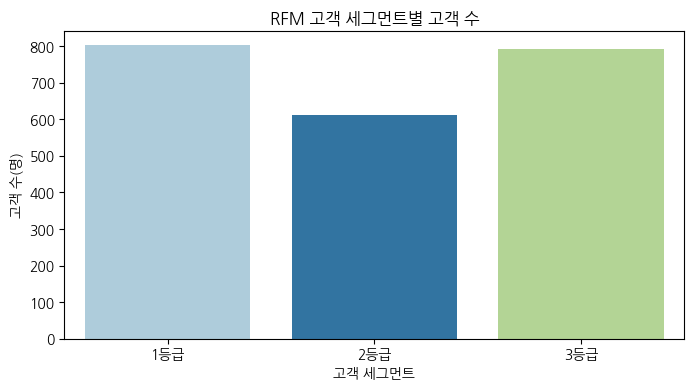

In [477]:
# 조정된 가중치가 적용된  RFM 고객 세그먼트별 고객 수 시각화
plt.rcParams["figure.figsize"] = (8, 4)
sns.countplot(data=customer_df, 
              x="rfm_segment2",
              order=grade_labels,
              palette="Paired"
             )
plt.title("RFM 고객 세그먼트별 고객 수")
plt.xlabel("고객 세그먼트")
plt.ylabel("고객 수(명)")
plt.xticks(ticks=range(0, num_grades), # num_grades=3
           labels=[f"{x}등급" for x in grade_labels]) 
plt.show()

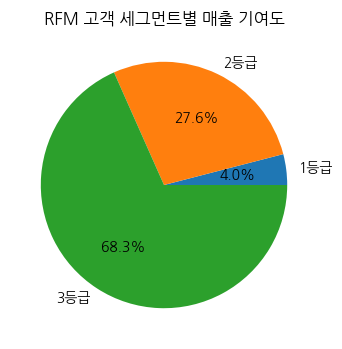

In [478]:
# 조정된 가중치가 적용된 RFM 고객 세그먼트별 매출 기여도 시각화
groupby_rfm_segment2 = customer_df.groupby("rfm_segment2").sum(numeric_only=True).reset_index()
groupby_rfm_segment2["amount_total"].plot(
    kind="pie",
    autopct="%.1f%%",
    labels=[f"{x}등급" for x in grade_labels],
    title="RFM 고객 세그먼트별 매출 기여도",
    figsize=(8, 4)
)
plt.show()

    → 매출 기여도가 높은 3등급 세그먼트를 핵심 고객 그룹으로 설정하여 집중 관리를 한다면 매출에 도움이 될 것으로 보임

#### **5-3. 세그먼트별 특성 및 소비 성향 분석**
 - 세그먼트별 연령대, 가족 구성 분포 파악
 - 세그먼트별 품목별 매출 기여도, 프로모션 참여율 파악

In [427]:
customer_df.head()

,signup_ym,age,age_group,annual_income,marital_status,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,recency_grade,frequency_grade,monetary_grade,rfm_score,rfm_segment,rfm_score2,rfm_segment2
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,2020-12,58,50대,75579400.0,미혼,0,58,825500,114400,709800,223600,114400,114400,2102100,8,4,3,15,0,0,0,0,0,1,2,2,3,2.333333,2,2.4,3
2174,2022-06,61,60대 이상,60247200.0,미혼,2,38,14300,1300,7800,2600,1300,7800,35100,1,2,2,5,0,0,0,0,0,0,2,1,1,1.333333,1,1.2,1
4141,2021-11,50,50대,93096900.0,배우자 있음,0,26,553800,63700,165100,144300,27300,54600,1008800,8,10,1,19,0,0,0,0,0,0,3,3,2,2.666667,3,2.6,3
6182,2022-05,31,30대,34639800.0,배우자 있음,1,26,14300,5200,26000,13000,3900,6500,68900,2,4,2,8,0,0,0,0,0,0,3,1,1,1.666667,1,1.4,1
5324,2022-04,34,30대,75780900.0,배우자 있음,1,94,224900,55900,153400,59800,35100,19500,548600,5,6,5,16,0,0,0,0,0,0,1,3,2,2.000000,2,2.2,2


* 연령대 분포

In [428]:
# 세그먼트별 연령대 분포 확인
groupby_rfm_segment_age_group = customer_df.groupby(["rfm_segment2", "age_group"]).size().reset_index()
groupby_rfm_segment_age_group # 고객 수

,rfm_segment2,age_group,0
0,1,20대 이하,84
1,1,30대,231
2,1,40대,268
3,1,50대,135
4,1,60대 이상,84
5,2,20대 이하,46
6,2,30대,121
7,2,40대,169
8,2,50대,161
9,2,60대 이상,114


In [429]:
# 고객 수 컬럼명 변경
groupby_rfm_segment_age_group = groupby_rfm_segment_age_group.rename(columns={0: "num_customers"})
groupby_rfm_segment_age_group

,rfm_segment2,age_group,num_customers
0,1,20대 이하,84
1,1,30대,231
2,1,40대,268
3,1,50대,135
4,1,60대 이상,84
5,2,20대 이하,46
6,2,30대,121
7,2,40대,169
8,2,50대,161
9,2,60대 이상,114


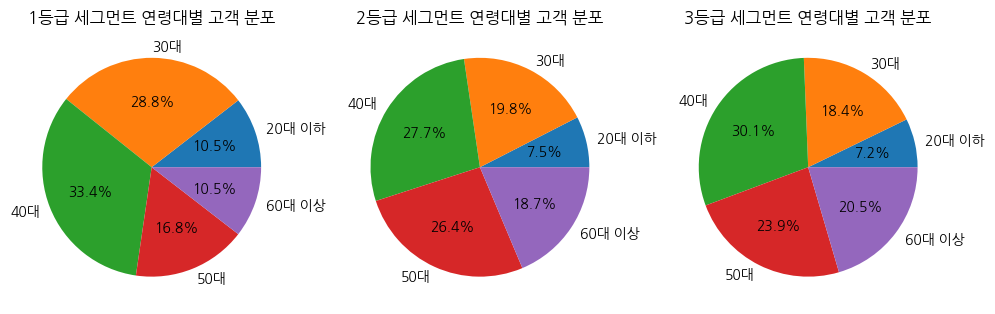

In [479]:
# 세그먼트별 연령대별 매출 기여도 시각화
for i_segment in range(1, num_grades + 1):
    plt.subplot(1, num_grades, i_segment) 
    age_group_dist = groupby_rfm_segment_age_group[
        groupby_rfm_segment_age_group["rfm_segment2"] == i_segment
    ]
    age_group_dist["num_customers"].plot(
        kind="pie",
        autopct="%.1f%%",
        labels=age_group_dist["age_group"].unique(),
        title=f"{i_segment}등급 세그먼트 연령대별 고객 분포",
        figsize=(12, 8)
    )
plt.show()

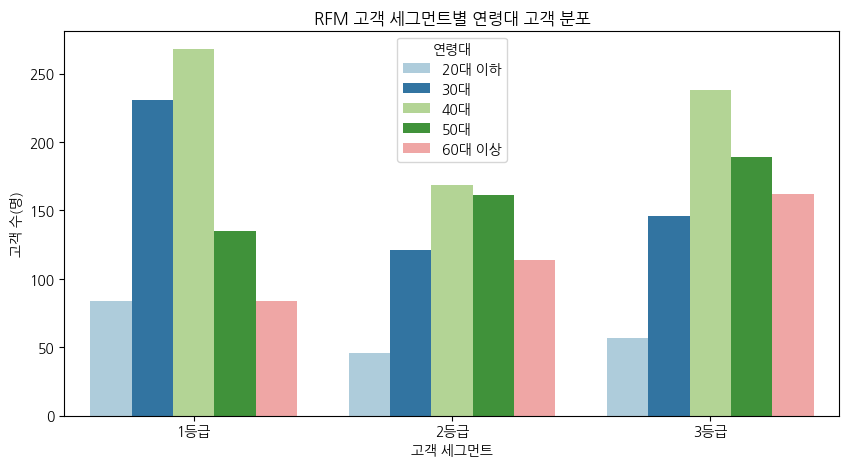

In [490]:
# 세그먼트별 연령대별 매출 기여도 시각화
plt.rcParams["figure.figsize"] = (10, 5)
sns.barplot(
    data=groupby_rfm_segment_age_group,
    x="rfm_segment2",
    y="num_customers",
    hue="age_group",
    palette="Paired"
)
plt.title("RFM 고객 세그먼트별 연령대 고객 분포")
plt.xlabel("고객 세그먼트")
plt.ylabel("고객 수(명)")
plt.xticks(ticks=range(num_grades), labels=[f"{x}등급" for x in grade_labels])
plt.legend(title="연령대")
plt.show()

    → 1등급 세그먼트 고객에 비해 2, 3등급은 30대 이하의 비중이 작음
    → 매출 기여도가 높은 3등급 세그먼트에 집중 마케팅을 전개한다면, 젊은 세대보다는 중장년층 타켓팅이 효과가 더 클 가능성이 있음

* 가족 구성 분포 - 혼인 상태, 부양 자녀 수

In [431]:
# 세그먼트별 혼인 상태 분포 확인
groupby_rfm_segment_marital = customer_df.groupby(["rfm_segment2", "marital_status"]).size().reset_index()
groupby_rfm_segment_marital = groupby_rfm_segment_marital.rename(columns={0: "num_customers"}) # 컬럼명 변경
groupby_rfm_segment_marital

,rfm_segment2,marital_status,num_customers
0,1,미혼,183
1,1,배우자 있음,522
2,1,사별,18
3,1,이혼,79
4,2,미혼,136
5,2,배우자 있음,390
6,2,사별,20
7,2,이혼,65
8,3,미혼,158
9,3,배우자 있음,510


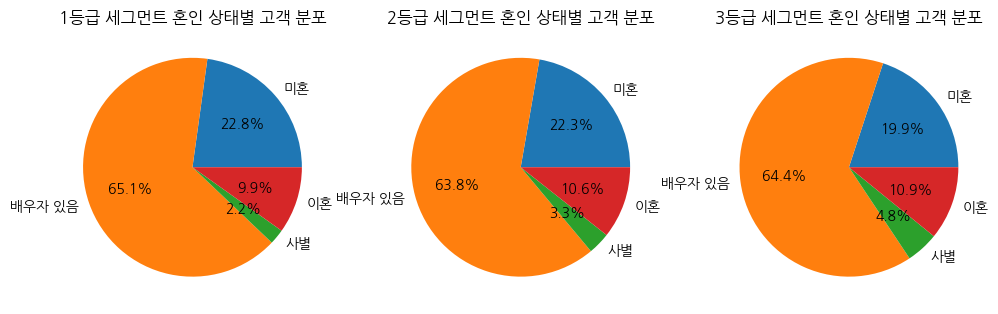

In [486]:
# 세그먼트별 혼인 상태별 매출 기여도 시각화
for i_segment in range(1, num_grades + 1):
    plt.subplot(1, num_grades, i_segment) 
    marital_status_dist = groupby_rfm_segment_marital[
            groupby_rfm_segment_marital["rfm_segment2"] == i_segment
        ]
    marital_status_dist["num_customers"].plot(
        kind="pie",
        autopct="%.1f%%",
        labels=marital_status_dist["marital_status"].unique(),
        title=f"{i_segment}등급 세그먼트 혼인 상태별 고객 분포",
        figsize=(12, 8)
    )
plt.show()

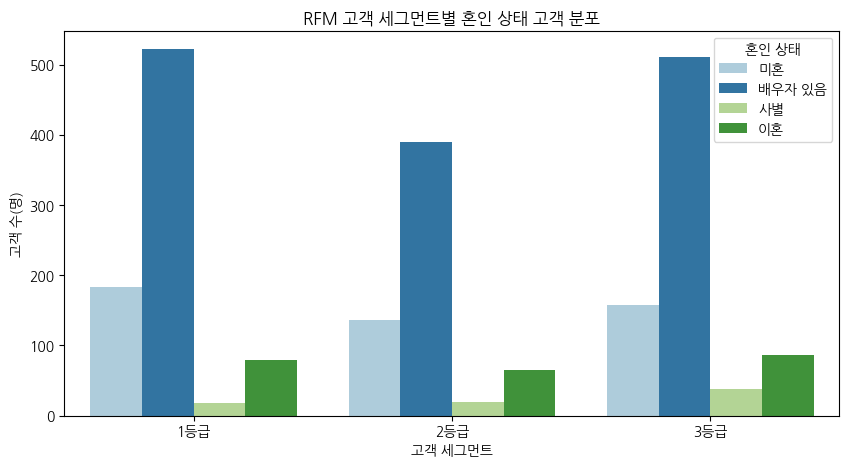

In [491]:
# 세그먼트별 혼인 상태별 매출 기여도 시각화
plt.rcParams["figure.figsize"] = (10, 5)
sns.barplot(
    data=groupby_rfm_segment_marital,
    x="rfm_segment2",
    y="num_customers",
    hue="marital_status",
    palette="Paired"
)
plt.title("RFM 고객 세그먼트별 혼인 상태 고객 분포")
plt.xlabel("고객 세그먼트")
plt.ylabel("고객 수(명)")
plt.xticks(ticks=range(num_grades), labels=[f"{x}등급" for x in grade_labels])
plt.legend(title="혼인 상태")
plt.show()

    → 혼인 상태의 분포는 세그먼트에 따라 큰 차이가 없음

In [433]:
# 세그먼트별 부양 자녀 수 분포 확인
groupby_rfm_segment_children  = customer_df.groupby(["rfm_segment2", "children"]).size().reset_index()
groupby_rfm_segment_children  = groupby_rfm_segment_children.rename(columns={0: "num_customers"}) # 컬럼명 변경
groupby_rfm_segment_children 

,rfm_segment2,children,num_customers
0,1,0,101
1,1,1,437
2,1,2,232
3,1,3,32
4,2,0,189
5,2,1,308
6,2,2,105
7,2,3,9
8,3,0,338
9,3,1,367


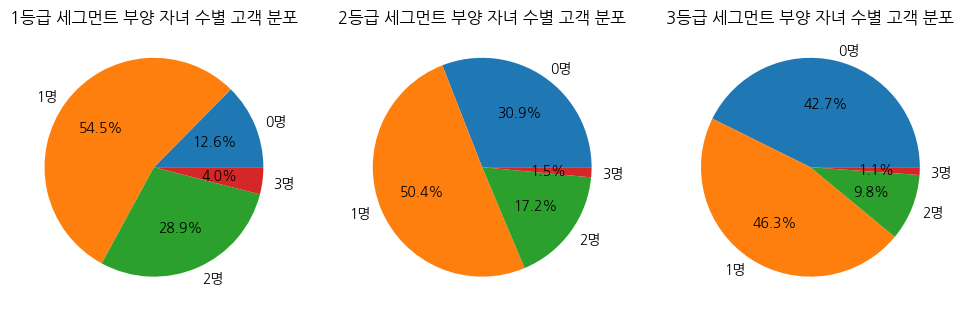

In [493]:
# 세그먼트별 부양 자녀 수별 매출 기여도 시각화
for i_segment in range(1, num_grades + 1):
    plt.subplot(1, num_grades, i_segment) 
    children_dist = groupby_rfm_segment_children[
                groupby_rfm_segment_children["rfm_segment2"] == i_segment
        ]
    children_dist["num_customers"].plot(
        kind="pie",
        autopct="%.1f%%",
        labels=[f"{i}명" for i in children_dist["children"].unique()],
        title=f"{i_segment}등급 세그먼트 부양 자녀 수별 고객 분포",
        figsize=(12, 8)
    )
plt.show()

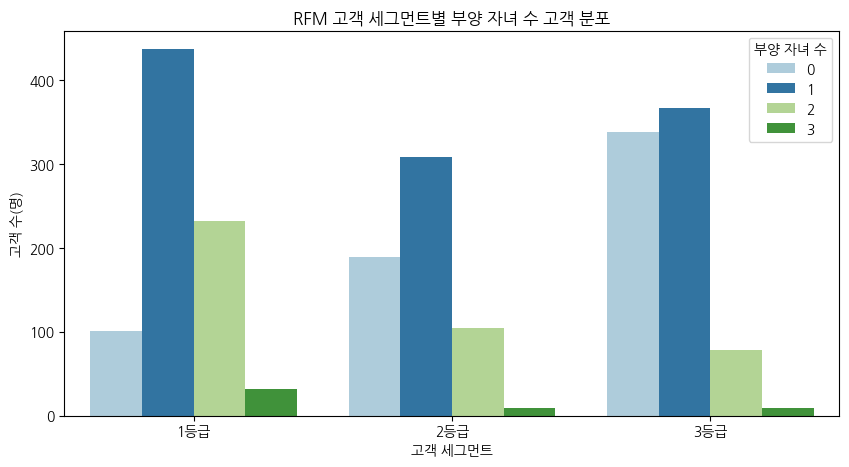

In [496]:
# 세그먼트별 부양 자녀 수별 매출 기여도 시각화
plt.rcParams["figure.figsize"] = (10, 5)
sns.barplot(
    data=groupby_rfm_segment_children,
    x="rfm_segment2",
    y="num_customers",
    hue="children",
    palette="Paired"
)
plt.title("RFM 고객 세그먼트별 부양 자녀 수 고객 분포")
plt.xlabel("고객 세그먼트")
plt.ylabel("고객 수(명)")
plt.xticks(ticks=range(num_grades), labels=[f"{x}등급" for x in grade_labels])
plt.legend(title="부양 자녀 수")
plt.show()

    → 1등급에서 3등급으로 갈수록 자녀가 없는 고객의 비중이 매우 큼
    → 3등급 세그먼트에는 무자녀 고객이 40%를 넘으므로, 이러한 특성을 마케팅 전략에 반영할 필요성이 있음

* 품목별 매출 기여도

In [516]:
# 세그먼트별 각 품목의 매출 합계 확인
groupby_rfm_segment = customer_df.groupby("rfm_segment2").sum(numeric_only=True).reset_index() # 품목별로 매출 합
groupby_rfm_segment

,rfm_segment2,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,rfm_score,rfm_segment,rfm_score2
0,1,34844,3.401424e+10,997,40993,26176800,4089800,16556800,6091800,4165200,13079300,70159700,1336,2340,1386,5062,0,2,57,5,1,60,1089.333333,802,996.6
1,2,28808,4.383286e+10,545,34358,231695100,22575800,133016000,31023200,22217000,39907400,480434500,2738,3529,1585,7852,31,6,44,48,37,78,1224.333333,1098,1250.8
2,3,37989,7.012763e+10,550,32714,619749000,49019100,324294100,71113900,51381200,73303100,1188860400,4968,6972,2141,14081,111,22,62,111,123,195,2045.000000,2052,2096.6


In [517]:
# 품목별 매출이 담긴 데이터만 추출
selected_columns = [
    col
    for col in groupby_rfm_segment.columns
    if col.startswith("amount_") and col != "amount_total" # 컬럼명 기준. amount로 시작하는 컬럼
]
selected_columns.append("rfm_segment2")
selected_columns

['amount_alcohol',
 'amount_fruit',
 'amount_meat',
 'amount_fish',
 'amount_snack',
 'amount_general',
 'rfm_segment2']

In [518]:
# 세그먼트별 각 품목의 매출 합계
amount_sum_per_product = groupby_rfm_segment[selected_columns]
amount_sum_per_product = amount_sum_per_product.set_index('rfm_segment2')
amount_sum_per_product

,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general
rfm_segment2,,,,,,
1,26176800,4089800,16556800,6091800,4165200,13079300
2,231695100,22575800,133016000,31023200,22217000,39907400
3,619749000,49019100,324294100,71113900,51381200,73303100


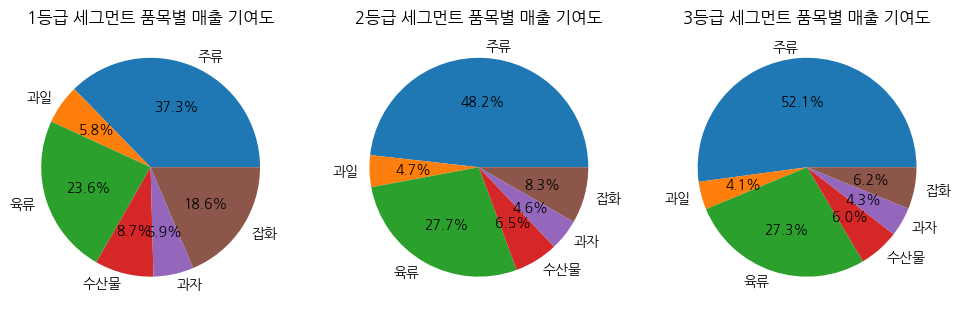

In [519]:
# 세그먼트별 품목별 매출 기여도 시각화
for i_segment in range(1, num_grades + 1):
    plt.subplot(1, num_grades, i_segment) 
    amount_sum_per_product.loc[i_segment].plot(
        kind="pie",
        autopct="%.1f%%",
        labels=["주류", "과일", "육류", "수산물", "과자", "잡화"],
        title=f"{i_segment}등급 세그먼트 품목별 매출 기여도",
        figsize=(12, 8)
    )
plt.show()

In [535]:
# 그래프를 그리기 위해, 인덱스를 풀고 데이터를 long format 으로 변환
amount_sum_per_product2 = groupby_rfm_segment[selected_columns]
amount_sum_per_product2 = amount_sum_per_product2.melt(
    id_vars="rfm_segment2",
    var_name="product",
    value_name="sales"
)

product_labels = {
    "amount_alcohol": "주류",
    "amount_fruit": "과일",
    "amount_meat": "육류",
    "amount_fish": "수산물",
    "amount_snack": "과자",
    "amount_general": "잡화"
}
amount_sum_per_product2["product"] = amount_sum_per_product2["product"].replace(product_labels)
amount_sum_per_product2.head()

,rfm_segment2,product,sales
0,1,주류,26176800
1,2,주류,231695100
2,3,주류,619749000
3,1,과일,4089800
4,2,과일,22575800


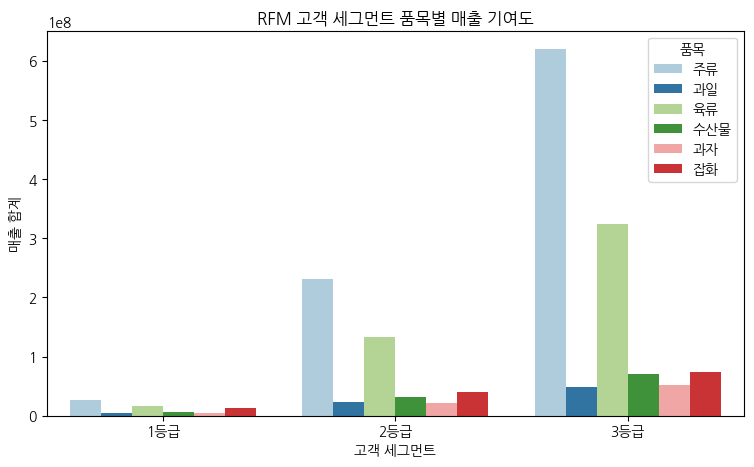

In [575]:
# 세그먼트별 품목별 매출 기여도 시각화
current_values = plt.gca().get_yticks()

plt.rcParams["figure.figsize"] = (10, 5)
sns.barplot(
    data=amount_sum_per_product2,
    x="rfm_segment2",
    y="sales",
    hue="product",
    palette="Paired"
)
plt.title("RFM 고객 세그먼트 품목별 매출 기여도")
plt.xlabel("고객 세그먼트")
plt.ylabel("매출 합계")
plt.xticks(ticks=range(num_grades), labels=[f"{x}등급" for x in grade_labels])
plt.legend(title="품목")
plt.ylim(bottom=0)
plt.show()

    → 세그먼트에 따라 뚜렷하게 매출 기여도가 달라지는 품목은 주류와 잡화임
    → 앞서 1등급에서 3등급으로 갈수록 자녀의 수가 줄어드는 경향성이 있었는데,
      이는 3등급의 주류 소비 비율 증가 및 잡화 소비 비율 감소와도 연관성이 있을 것임

* 프로모션 참여율 파악 (참여여부 1, 0)

In [560]:
# 세그먼트별 프로모션 참여율 확인
groupby_rfm_segment = customer_df.groupby("rfm_segment2").mean(numeric_only=True).reset_index() # 평균으로 참여율 계산
groupby_rfm_segment

,rfm_segment2,age,annual_income,children,recency,amount_alcohol,amount_fruit,amount_meat,amount_fish,amount_snack,amount_general,amount_total,num_purchase_web,num_purchase_store,num_purchase_discount,num_purchase_total,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6,rfm_score,rfm_segment,rfm_score2
0,1,43.446384,4.241177e+07,1.243142,51.113466,32639.401496,5099.501247,20644.389027,7595.760599,5193.516209,16308.354115,8.748092e+04,1.665835,2.917706,1.728180,6.311721,0.000000,0.002494,0.071072,0.006234,0.001247,0.074813,1.358271,1.000000,1.242643
1,2,47.148936,7.173954e+07,0.891980,56.232406,379206.382979,36948.936170,217702.127660,50774.468085,36361.702128,65314.893617,7.863085e+05,4.481178,5.775777,2.594108,12.851064,0.050736,0.009820,0.072013,0.078560,0.060556,0.127660,2.003819,1.797054,2.047136
2,3,47.965909,8.854499e+07,0.694444,41.305556,782511.363636,61892.803030,409462.247475,89790.277778,64875.252525,92554.419192,1.501086e+06,6.272727,8.803030,2.703283,17.779040,0.140152,0.027778,0.078283,0.140152,0.155303,0.246212,2.582071,2.590909,2.647222


In [561]:
# 세그먼트 등급과 프로모션별 참여율이 담긴 데이터만 추출
selected_columns = [f"promotion_{i}" for i in range(1, 7)] # promotion으로 시작하는 컬럼
selected_columns.append("rfm_segment2")
selected_columns

['promotion_1',
 'promotion_2',
 'promotion_3',
 'promotion_4',
 'promotion_5',
 'promotion_6',
 'rfm_segment2']

In [562]:
# 세그먼트별 각 프로모션 참여율
avg_promotion = groupby_rfm_segment[selected_columns]
avg_promotion = avg_promotion.set_index("rfm_segment2")
avg_promotion

,promotion_1,promotion_2,promotion_3,promotion_4,promotion_5,promotion_6
rfm_segment2,,,,,,
1,0.000000,0.002494,0.071072,0.006234,0.001247,0.074813
2,0.050736,0.009820,0.072013,0.078560,0.060556,0.127660
3,0.140152,0.027778,0.078283,0.140152,0.155303,0.246212


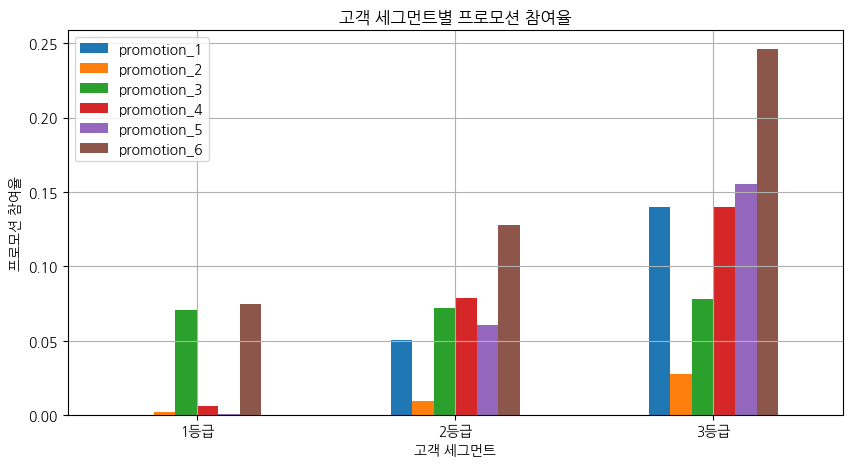

In [572]:
# 세그먼트별 각 프로모션 참여율 시각화
plt.rcParams["figure.figsize"] = (10, 5)
avg_promotion.plot(kind="bar", rot=0.5)
plt.title("고객 세그먼트별 프로모션 참여율")
plt.xlabel("고객 세그먼트")
plt.ylabel("프로모션 참여율")
plt.xticks(ticks=range(0, num_grades), # num_grades=3
           labels=[f"{x}등급" for x in grade_labels]) 
plt.grid()
plt.show()

    → 1등급에서 3등급으로 갈수록 전체적으로 프로모션 참여율이 증가함
    → 3등급 세그먼트 고객을 타깃으로 프로모션을 진행한다면 1, 4, 5, 6의 참여율이 높았다는 점을 참고할 필요가 있음